## Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Define the ODE System
We'll write a function that returns the derivatives.

In [14]:
# Cell 2: Revised ODE system with non‑negative R
def malaria_model(t, y, S, k1, k2, k3, k4, k5, d1, d2, d3, d4,
                  K_inh, n_inh, a1, a2, K_fb, n_fb,
                  K_R, n_R):   # new parameters for R inhibition
    """
    Variables: y = [N, M, I, R]
    N: NF-κB activity
    M: MAPK activity
    I: Inflammatory output
    R: Regulatory module (CTLA‑4, SIRT1, SMAD7, etc.)

    Parameters:
        S, k1, k2, k3, k4, k5, d1..d4, K_inh, n_inh, a1, a2, K_fb, n_fb:
            as before (k5 is now unused but kept for compatibility)
        K_R, n_R: Hill parameters for inhibition of R production by I
    """
    N, M, I, R = y

    # Inhibition of N/M and I by R (saturating)
    inhibition_R_on_NM = (R**n_inh) / (K_inh**n_inh + R**n_inh)

    # Positive feedback from I onto N and M
    feedback_NM = (I**n_fb) / (K_fb**n_fb + I**n_fb)

    # Inhibition of R production by I (saturating)
    inhibition_I_on_R = (I**n_R) / (K_R**n_R + I**n_R)

    dNdt = k1 * S * (1 - inhibition_R_on_NM) + a1 * feedback_NM - d1 * N
    dMdt = k2 * S * (1 - inhibition_R_on_NM) + a2 * feedback_NM - d2 * M
    dIdt = k3 * (N + M) * (1 - inhibition_R_on_NM) - d3 * I

    # R production is reduced by I, but never negative
    dRdt = k4 * S * (1 - inhibition_I_on_R) - d4 * R

    return [dNdt, dMdt, dIdt, dRdt]

## Set Parameters and Simulate Two Scenarios
We need to choose parameters that allow bistability. We'll try a set and simulate from two different initial conditions: one representing a "symptomatic" state (high N,M,I, low R) and one representing an "asymptomatic" state (low N,M,I, high R). We'll see if the system converges to different steady states depending on initial condition, or if it always converges to the same state. If not, we can adjust parameters (especially the Hill coefficient and thresholds) to get bistability.

We'll start with arbitrary parameters that are biologically plausible but may need tuning. We'll explain that parameter values are not fitted; they are chosen to illustrate the concept.

In [15]:
# Cell 3: Set parameters and initial conditions
# We keep most parameters as before but add K_R and n_R.
# k5 is no longer used but we keep it in the list for compatibility.
S = 1.0
k1 = 0.5
k2 = 0.5
k3 = 1.0
k4 = 1.0          # basal R production (will be suppressed by I)
k5 = 0.2          # (unused now)
d1 = 0.1
d2 = 0.1
d3 = 0.5
d4 = 0.1

K_inh = 2.0
n_inh = 4
a1 = 3.0
a2 = 2.0
K_fb = 4.0
n_fb = 2

# New parameters for R inhibition
K_R = 5.0         # half‑max for inhibition of R by I
n_R = 2           # cooperativity

# Parameters tuple (order must match malaria_model)
params = (S, k1, k2, k3, k4, k5, d1, d2, d3, d4,
          K_inh, n_inh, a1, a2, K_fb, n_fb,
          K_R, n_R)

# Time span (longer for sweeps)
t_span = (0, 200)
t_eval = np.linspace(0, 200, 2000)

# Two initial conditions: symptomatic (high I, low R) and asymptomatic (low I, high R)
y0_sympt = [5.0, 5.0, 10.0, 0.5]
y0_asympt = [0.5, 0.5, 1.0, 5.0]

sol_sympt = solve_ivp(malaria_model, t_span, y0_sympt, args=params,
                      t_eval=t_eval, method='LSODA')
sol_asympt = solve_ivp(malaria_model, t_span, y0_asympt, args=params,
                       t_eval=t_eval, method='LSODA')

## Plot the Time Courses
We'll plot I (inflammatory output) and R (regulatory module) for both scenarios to see if they converge to different steady states.

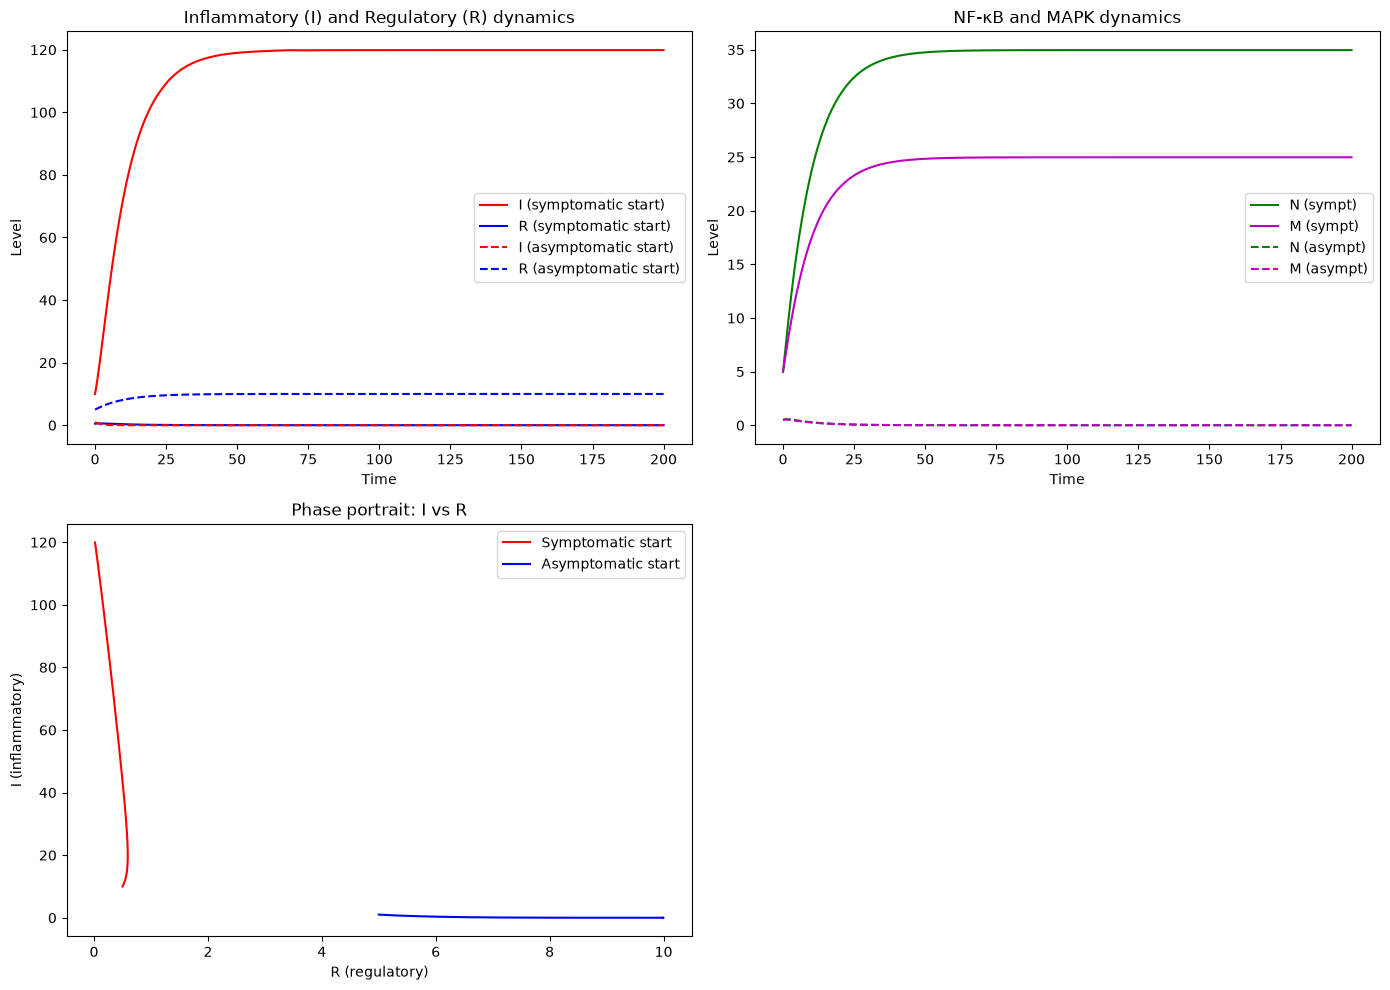

In [16]:
# Cell 4: Plot time courses (I and R, and phase portrait)
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(sol_sympt.t, sol_sympt.y[2], 'r-', label='I (symptomatic start)')
plt.plot(sol_sympt.t, sol_sympt.y[3], 'b-', label='R (symptomatic start)')
plt.plot(sol_asympt.t, sol_asympt.y[2], 'r--', label='I (asymptomatic start)')
plt.plot(sol_asympt.t, sol_asympt.y[3], 'b--', label='R (asymptomatic start)')
plt.xlabel('Time')
plt.ylabel('Level')
plt.legend()
plt.title('Inflammatory (I) and Regulatory (R) dynamics')

plt.subplot(2, 2, 2)
plt.plot(sol_sympt.t, sol_sympt.y[0], 'g-', label='N (sympt)')
plt.plot(sol_sympt.t, sol_sympt.y[1], 'm-', label='M (sympt)')
plt.plot(sol_asympt.t, sol_asympt.y[0], 'g--', label='N (asympt)')
plt.plot(sol_asympt.t, sol_asympt.y[1], 'm--', label='M (asympt)')
plt.xlabel('Time')
plt.ylabel('Level')
plt.legend()
plt.title('NF‑κB and MAPK dynamics')

plt.subplot(2, 2, 3)
plt.plot(sol_sympt.y[3], sol_sympt.y[2], 'r-', label='Symptomatic start')
plt.plot(sol_asympt.y[3], sol_asympt.y[2], 'b-', label='Asymptomatic start')
plt.xlabel('R (regulatory)')
plt.ylabel('I (inflammatory)')
plt.legend()
plt.title('Phase portrait: I vs R')

plt.tight_layout()
plt.savefig('/workspaces/Malaria-host-response-systems/results/figures/dynamic_model_bistability_revised.png', dpi=150)
plt.show()

## Check Steady-State Values
Print final values to see if they differ.

In [17]:
# Cell 5: Check steady‑state values (now R should be non‑negative)
print("Symptomatic start final I, R:", sol_sympt.y[2, -1], sol_sympt.y[3, -1])
print("Asymptomatic start final I, R:", sol_asympt.y[2, -1], sol_asympt.y[3, -1])

Symptomatic start final I, R: 119.88879244467927 0.017363270426769686
Asymptomatic start final I, R: 5.103629973501525e-05 10.00000019283549


### Define a Helper Function to Simulate and Get Final I

In [18]:
# Cell 6: Helper function for sweeps (now with longer time)
def simulate_final_I(params_tuple, y0=[5.0, 5.0, 10.0, 0.5], t_end=200):
    """Simulate the model and return the final I value."""
    sol = solve_ivp(malaria_model, [0, t_end], y0, args=params_tuple,
                    t_eval=np.linspace(0, t_end, 1000), method='LSODA')
    return sol.y[2, -1]

### Vary k4 (basal regulatory production)
This simulates the effect of increasing regulatory module (e.g., SIRT1 agonists).

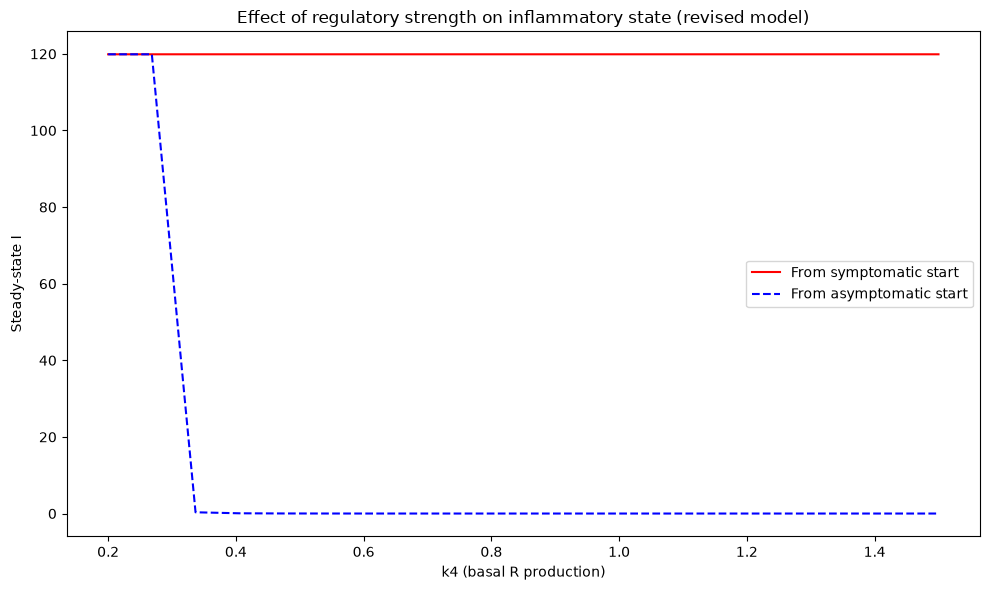

In [19]:
# Cell 7: Vary k4 (basal regulatory production) – now with the new model
# Index of k4 is 4 in params tuple (order: S, k1, k2, k3, k4, k5, d1, d2, d3, d4, K_inh, n_inh, a1, a2, K_fb, n_fb, K_R, n_R)
k4_values = np.linspace(0.2, 1.5, 20)
I_high = []
I_low = []

for k4 in k4_values:
    p = list(params)
    p[4] = k4
    new_params = tuple(p)
    I_high.append(simulate_final_I(new_params, y0=[5,5,10,0.5]))
    I_low.append(simulate_final_I(new_params, y0=[0.5,0.5,1,5]))

plt.figure(figsize=(10,6))
plt.plot(k4_values, I_high, 'r-', label='From symptomatic start')
plt.plot(k4_values, I_low, 'b--', label='From asymptomatic start')
plt.xlabel('k4 (basal R production)')
plt.ylabel('Steady‑state I')
plt.legend()
plt.title('Effect of regulatory strength on inflammatory state (revised model)')
plt.tight_layout()
plt.savefig('/workspaces/Malaria-host-response-systems/results/figures/perturbation_k4_revised.png', dpi=150)
plt.show()

### Vary a1 (positive feedback strength to NF-κB)
This simulates inhibiting NF-κB activation (e.g., IKK inhibitors).

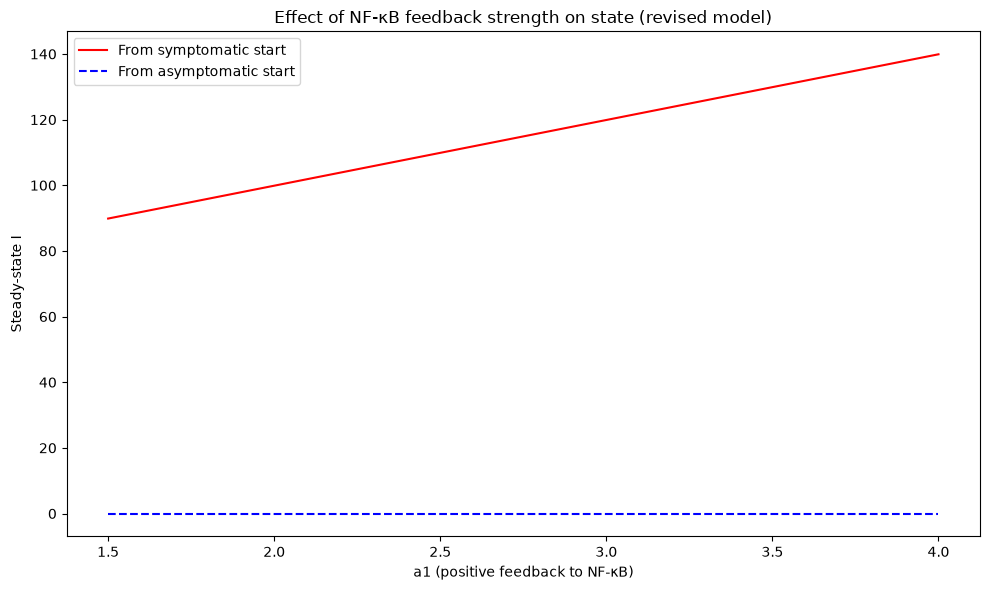

In [20]:
# Cell 8: Vary a1 (positive feedback to NF‑κB) – with revised model
# Index of a1 is 12
a1_values = np.linspace(1.5, 4.0, 20)
I_high = []
I_low = []

for a1 in a1_values:
    p = list(params)
    p[12] = a1                     # <--- changed from p[1] to p[12]
    new_params = tuple(p)
    I_high.append(simulate_final_I(new_params, y0=[5,5,10,0.5]))
    I_low.append(simulate_final_I(new_params, y0=[0.5,0.5,1,5]))

plt.figure(figsize=(10,6))
plt.plot(a1_values, I_high, 'r-', label='From symptomatic start')
plt.plot(a1_values, I_low, 'b--', label='From asymptomatic start')
plt.xlabel('a1 (positive feedback to NF‑κB)')
plt.ylabel('Steady‑state I')
plt.legend()
plt.title('Effect of NF‑κB feedback strength on state (revised model)')
plt.tight_layout()
plt.savefig('/workspaces/Malaria-host-response-systems/results/figures/perturbation_a1_revised.png', dpi=150)
plt.show()

In [21]:
print("a1 values:", a1_values)
print("I_high:", I_high)
print("I_low:", I_low)

a1 values: [1.5        1.63157895 1.76315789 1.89473684 2.02631579 2.15789474
 2.28947368 2.42105263 2.55263158 2.68421053 2.81578947 2.94736842
 3.07894737 3.21052632 3.34210526 3.47368421 3.60526316 3.73684211
 3.86842105 4.        ]
I_high: [np.float64(89.86156706953936), np.float64(92.49599673322112), np.float64(95.13032499550164), np.float64(97.76457151121664), np.float64(100.39871633298587), np.float64(103.03275332062098), np.float64(105.6667199596268), np.float64(108.30059261018089), np.float64(110.93439800672292), np.float64(113.56813356296465), np.float64(116.20178623572703), np.float64(118.83538463187763), np.float64(121.46893064515007), np.float64(124.10235365279536), np.float64(126.73574928510706), np.float64(129.3691438844229), np.float64(132.0026101764084), np.float64(134.63564688307778), np.float64(137.26885141191661), np.float64(139.90198328526895)]
I_low: [np.float64(5.1040141211812886e-05), np.float64(5.1040174827775594e-05), np.float64(5.104044066142811e-05), np.floa